# 1. Baseline LLM: Comparisons between control and gamified tool unlock

This notebook analyzes the `GAIA` question performance of the baseline LLM vs GAMIFIED tool system across multiple seeds (42, 43, 44).

It addresses:
- Compare difference in question selection (based off category and level): All
- Compare overall accuracy: All
- Compare category accuracy: All
- Compare question category selection: All

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

# Load parsed data
with open('../scripts/parsed_data.json', 'r') as f:
    data = json.load(f)

questions = []
for run in data:
    for q in run['questions_attempted']:
        questions.append(q)

df_run = pd.DataFrame([{
    'seed': r['seed'],
    'mode': r['mode'],
    'rooms_visited': r['final_state'].get('rooms_visited', 0),
    'correct_count': r['final_state'].get('correct_count', 0),
    'wrong_count': r['final_state'].get('wrong_count', 0),
    'skills_unlocked_count': r['final_state'].get('skills_unlocked_count', 0)
} for r in data])

df_q = pd.DataFrame(questions)
df_q['is_correct'] = df_q['is_correct'].astype(int)
display(df_run)

,seed,mode,rooms_visited,correct_count,wrong_count,skills_unlocked_count
0,43,control,9,4,5,0
1,42,tool,7,3,4,3
2,44,tool,7,3,4,3
3,42,control,6,3,3,0
4,43,tool,5,1,4,1
5,44,control,7,2,5,0


## 1.1 Compare overall accuracy: All

,mode,accuracy,correct_answers,total_attempted
0,control,40.91,9,22
1,tool,36.84,7,19


/tmp/ipykernel_247386/2580793517.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall_accuracy, x='mode', y='accuracy', palette='viridis')


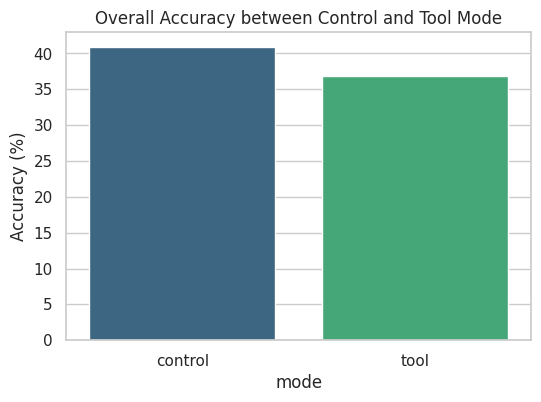

In [4]:
overall_accuracy = df_q.groupby('mode')['is_correct'].agg(['mean', 'sum', 'count']).reset_index()
overall_accuracy.rename(columns={'mean': 'accuracy', 'sum': 'correct_answers', 'count': 'total_attempted'}, inplace=True)
overall_accuracy['accuracy'] = (overall_accuracy['accuracy'] * 100).round(2)
display(overall_accuracy)

plt.figure(figsize=(6,4))
sns.barplot(data=overall_accuracy, x='mode', y='accuracy', palette='viridis')
plt.title('Overall Accuracy between Control and Tool Mode')
plt.ylabel('Accuracy (%)')
plt.show()

## 1.2 Compare category accuracy: All

,mode,category,accuracy,attempted
0,control,"Arts, Literature & Museums",0.00,1
1,control,History & Politics,100.00,1
6,tool,History & Politics,0.00,1
2,control,"Language, Linguistics & Cryptography",50.00,2
7,tool,"Language, Linguistics & Cryptography",0.00,1
8,tool,Other,0.00,1
3,control,Pop Culture & Entertainment,0.00,1
9,tool,Pop Culture & Entertainment,66.67,3
4,control,Science & Mathematics,33.33,12
10,tool,Science & Mathematics,25.00,8


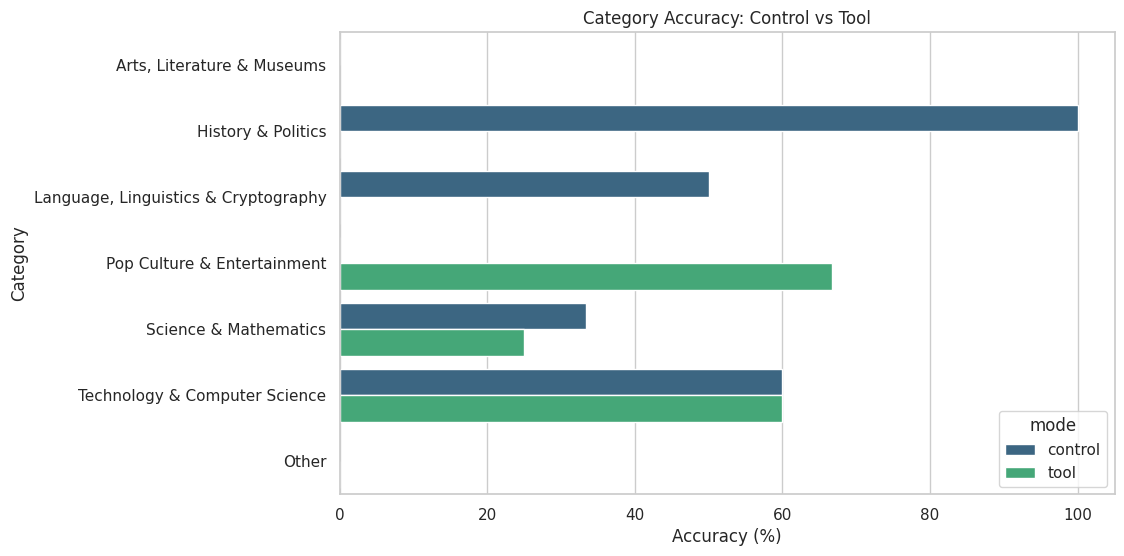

In [5]:
cat_acc = df_q.groupby(['mode', 'category'])['is_correct'].agg(['mean', 'count']).reset_index()
cat_acc.rename(columns={'mean': 'accuracy', 'count': 'attempted'}, inplace=True)
cat_acc['accuracy'] = (cat_acc['accuracy'] * 100).round(2)
display(cat_acc.sort_values(by=['category', 'mode']))

plt.figure(figsize=(10,6))
sns.barplot(data=cat_acc, x='accuracy', y='category', hue='mode', palette='viridis')
plt.title('Category Accuracy: Control vs Tool')
plt.xlabel('Accuracy (%)')
plt.ylabel('Category')
plt.show()

## 1.3 Compare question category selection: All

This checks if the agent tends to select different categories of questions when playing in the `tool` mode compared to the baseline `control` mode.

,mode,category,selection_count,percentage
0,control,"Arts, Literature & Museums",1,4.55
1,control,History & Politics,1,4.55
6,tool,History & Politics,1,5.26
2,control,"Language, Linguistics & Cryptography",2,9.09
7,tool,"Language, Linguistics & Cryptography",1,5.26
8,tool,Other,1,5.26
3,control,Pop Culture & Entertainment,1,4.55
9,tool,Pop Culture & Entertainment,3,15.79
4,control,Science & Mathematics,12,54.55
10,tool,Science & Mathematics,8,42.11


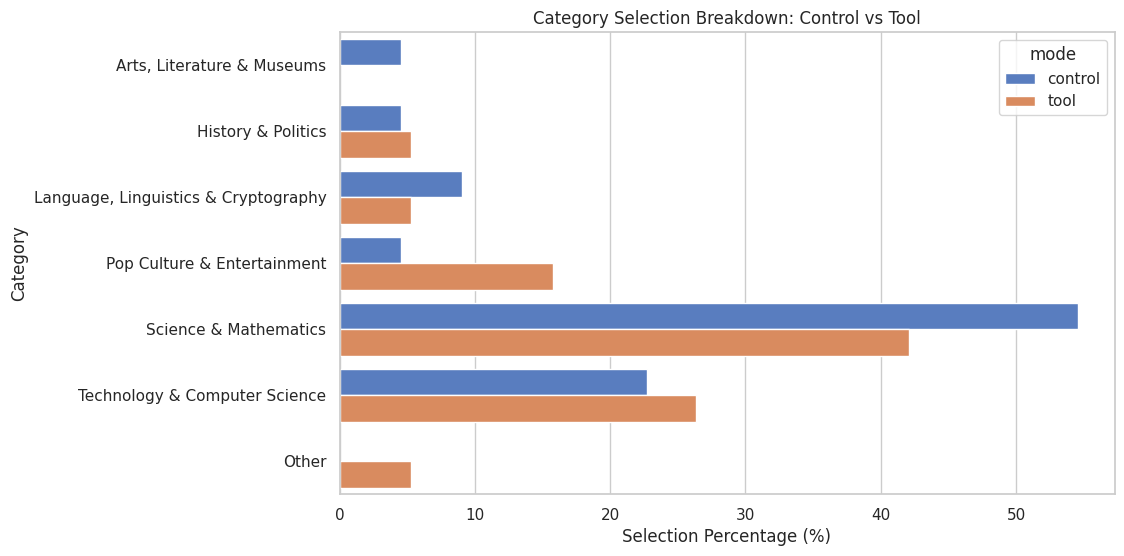

In [6]:
cat_selection = df_q.groupby(['mode', 'category']).size().reset_index(name='selection_count')

total_per_mode = df_q.groupby('mode').size().reset_index(name='total')
cat_selection = pd.merge(cat_selection, total_per_mode, on='mode')
cat_selection['percentage'] = (cat_selection['selection_count'] / cat_selection['total'] * 100).round(2)

display(cat_selection[['mode', 'category', 'selection_count', 'percentage']].sort_values(by=['category', 'mode']))

plt.figure(figsize=(10,6))
sns.barplot(data=cat_selection, x='percentage', y='category', hue='mode', palette='muted')
plt.title('Category Selection Breakdown: Control vs Tool')
plt.xlabel('Selection Percentage (%)')
plt.ylabel('Category')
plt.show()

## 1.4 Compare question selection (based off level): All

,mode,level,count,percentage
0,control,1,9,40.91
1,control,2,7,31.82
2,control,3,6,27.27
3,tool,1,6,31.58
4,tool,2,8,42.11
5,tool,3,5,26.32


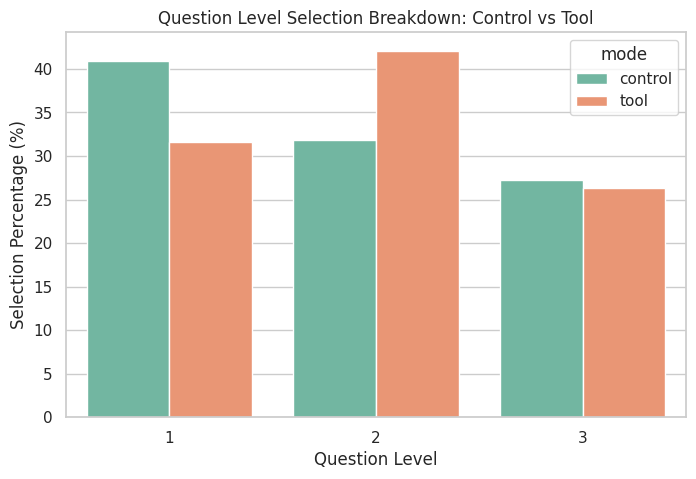

In [8]:
level_selection = df_q.groupby(['mode', 'level']).size().reset_index(name='count')
level_selection = pd.merge(level_selection, total_per_mode, on='mode')
level_selection['percentage'] = (level_selection['count'] / level_selection['total'] * 100).round(2)

display(level_selection[['mode', 'level', 'count', 'percentage']])

plt.figure(figsize=(8,5))
sns.barplot(data=level_selection, x='level', y='percentage', hue='mode', palette='Set2')
plt.title('Question Level Selection Breakdown: Control vs Tool')
plt.xlabel('Question Level')
plt.ylabel('Selection Percentage (%)')
plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(14,6), sharey=True)
# sns.histplot(data=df_q[df_q['mode']=='control'], x="category", hue="level", multiple="stack", ax=ax[0])
# ax[0].set_title('Control: Question Selection (Category & Level)')
# ax[0].tick_params(axis='x', rotation=90)

# sns.histplot(data=df_q[df_q['mode']=='tool'], x="category", hue="level", multiple="stack", ax=ax[1])
# ax[1].set_title('Tool: Question Selection (Category & Level)')
# ax[1].tick_params(axis='x', rotation=90)
# plt.tight_layout()
# plt.show()

## 1.5 Compare accuracy across different levels: Both modes

,mode,level,accuracy,attempted
0,control,1,66.67,9
1,control,2,14.29,7
2,control,3,33.33,6
3,tool,1,83.33,6
4,tool,2,25.00,8
5,tool,3,0.00,5


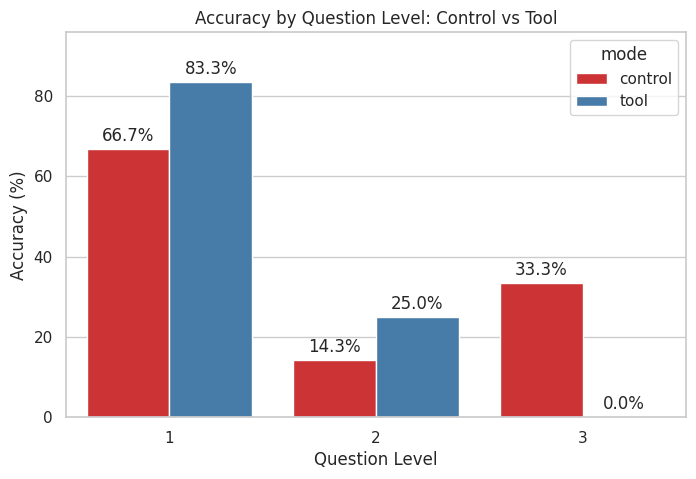

In [9]:
level_acc = df_q.groupby(['mode', 'level'])['is_correct'].agg(['mean', 'count']).reset_index()
level_acc.rename(columns={'mean': 'accuracy', 'count': 'attempted'}, inplace=True)
level_acc['accuracy'] = (level_acc['accuracy'] * 100).round(2)
display(level_acc)

plt.figure(figsize=(8,5))
sns.barplot(data=level_acc, x='level', y='accuracy', hue='mode', palette='Set1')
plt.title('Accuracy by Question Level: Control vs Tool')
plt.xlabel('Question Level')
plt.ylabel('Accuracy (%)')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.margins(y=0.15)
plt.show()